# ¡Hola Natalia! <a class="tocSkip"></a>

Mi nombre es Oscar Flores y tengo el gusto de revisar tu proyecto. Si tienes algún comentario que quieras agregar en tus respuestas te puedes referir a mi como Oscar, no hay problema que me trates de tú.

Si veo un error en la primera revisión solamente lo señalaré y dejaré que tú encuentres de qué se trata y cómo arreglarlo. Debo prepararte para que te desempeñes como especialista en Data, en un trabajo real, el responsable a cargo tuyo hará lo mismo. Si aún tienes dificultades para resolver esta tarea, te daré indicaciones más precisas en una siguiente iteración.

Te dejaré mis comentarios más abajo - **por favor, no los muevas, modifiques o borres**

Comenzaré mis comentarios con un resumen de los puntos que están bien, aquellos que debes corregir y aquellos que puedes mejorar. Luego deberás revisar todo el notebook para leer mis comentarios, los cuales estarán en rectángulos de color verde, amarillo o rojo como siguen:

<div class='alert alert-block alert-success'>
<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Muy bien! Toda la respuesta fue lograda satisfactoriamente.
</div>

<div class='alert alert-block alert-warning'>
<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Existen detalles a mejorar. Existen recomendaciones.
</div>

<div class='alert alert-block alert-danger'>

<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Se necesitan correcciones en el bloque. El trabajo no puede ser aceptado con comentarios en rojo sin solucionar.
</div>

Cualquier comentario que quieras agregar entre iteraciones de revisión lo puedes hacer de la siguiente manera:

<div class='alert alert-block alert-info'>
<b>Respuesta estudiante.</b> <a class='tocSkip'></a>
</div>

Mucho éxito en el proyecto!

## Resumen de la revisión v1 <a class="tocSkip"></a>

<div class="alert alert-block alert-danger">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Hola Natalia, ¿cómo estás? Espero que estés bien y avanzando con tranquilidad.

Felicitaciones por haber completado todos los ítems del notebook. El desarrollo está bien hecho y cumple con los requerimientos principales. Solo falta que agregues el análisis de clasificaciones ESRB en las regiones. Te dejé comentarios en rojo señalando los puntos específicos a corregir y además comentarios en amarillo con sugerencias.

Si necesitas ayuda o tienes alguna pregunta, puedes dejarla en azul, estaré encantado de responderla en la siguiente revisión.

¡Saludos!


</div>

## Resumen de la revisión v2 <a class="tocSkip"></a>

<div class="alert alert-block alert-success">
<b>Comentario de Revisor  v2 </b> <a class="tocSkip"></a>

Bien hecho Natalia, buen trabajo con las últimas correcciones. Has terminado completamente las tareas necesarias del notebook, no tengo comentarios de corrección adicionales, tu proyecto está aprobado. Los conocimientos que aplicaste aquí te serán muy útiles para análisis futuros, mucho éxito!

Saludos!

</div>

----

## Explorar dataset

In [2]:
# Cargar librerias a utilizar
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
# Crear dataframe
df = pd.read_csv('/datasets/games.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [5]:
df.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Excelente uso de las funciones de `head()` e `info()`. Esto permite observar claramente el tamaño de la data, donde hay nulos y ver una muestra. 

</div>

In [6]:
df.duplicated().sum()

0

In [7]:
df.isna().sum()

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
NA_sales              0
EU_sales              0
JP_sales              0
Other_sales           0
Critic_Score       8578
User_Score         6701
Rating             6766
dtype: int64

El dataset esta compuesto por 16,715 registros con 11 columnas, cuyos nombres contienen mayusculas.
Al parecer el dataset no contiene registros duplicados, sin embargo se detectan valores ausentes en columnas relevante, como por ejemplo "User_score", "Rating" y "Critic_score", ademas de valores ausentes en columnas impresindibles como "Name".
La columna de "Year_of_Release" tiene un dtype incorrecto de acuerdo a la información contenida, que no facilitara el analisis.

## Limpiar dataset

In [8]:
# Eliminar mayusculas de los nombres en las columnas
df.columns = df.columns.str.lower()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [9]:
# Analizar valores ausentes
(df.isna().mean() * 100).sort_values(ascending=False) 

critic_score       51.319174
rating             40.478612
user_score         40.089740
year_of_release     1.609333
name                0.011965
genre               0.011965
platform            0.000000
na_sales            0.000000
eu_sales            0.000000
jp_sales            0.000000
other_sales         0.000000
dtype: float64

In [10]:
# Eliminar valores ausentes importantes para el analisis
df = df.dropna(subset=['name','year_of_release']) # Se eliminan esos registros debido a su bajo porcentaje de significancía

In [11]:
# Cambiar tipos de datos
df['year_of_release'] = df['year_of_release'].astype('int64')

In [12]:
# Validar si existen registros con todas las ventas en "0"
df[(df['na_sales'] == 0)&(df['eu_sales'] == 0)&(df['jp_sales'] == 0)&(df['other_sales'] == 0)]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
16676,G1 Jockey 4 2008,PS3,2008,Sports,0.0,0.0,0.0,0.0,NaN,NaN,NaN
16709,SCORE International Baja 1000: The Official Game,PS2,2008,Racing,0.0,0.0,0.0,0.0,NaN,NaN,NaN


Se identificaron 2 registros con ventas iguales a 0 en todas las regiones, ademas de presentar valores ausentes en las columnas de score.
No se dispone de información suficiente para determinar el motivo de estas inconsistencias, y dado que  representan una fracción minima del dataset su eliminación no afecta de manera significativa el analisis. Por lo tanto, se decidió excluirlos para mantener la coherencia y calidad de los datos.

In [13]:
# Eliminar registros con ventas nulas
df = df.drop([16676,16709]).reset_index(drop=True)

In [14]:
# Convertir los "tbd" a NaN para realizar cambio de tipo a la columna "user_score"
df['user_score'] = df['user_score'].replace('tbd', pd.NA)
df['user_score'] = pd.to_numeric(df['user_score'])

In [15]:
# Asignar catgoria de desconocido a valores ausentes en "rating"
df['rating'] = df['rating'].fillna('No_rating')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16442 entries, 0 to 16441
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16442 non-null  object 
 1   platform         16442 non-null  object 
 2   year_of_release  16442 non-null  int64  
 3   genre            16442 non-null  object 
 4   na_sales         16442 non-null  float64
 5   eu_sales         16442 non-null  float64
 6   jp_sales         16442 non-null  float64
 7   other_sales      16442 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating           16442 non-null  object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

Bien hecho con la gestión de los valores ausentes. En los casos donde hay demasiados en una columna, me parece bien dejar los nulos tal como están o reemplazarlos por algún valor identificable. En este caso, para critic_score y user_score, no hay data suficiente para hacer una imputación adecuada y en caso de rellenar con la media o mediana, se introduce un sesgo muy fuerte en la data, por lo que no es adecuado.



</div>

## Añadir informacion

In [17]:
# Crear columna de ventas totales
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Muy bien, también podrías haber usado

```python
    df[['na_sales','jp_sales','eu_sales','other_sales']].sum(axis=1)
```
</div>

In [18]:
df

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,No_rating,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,No_rating,31.38
...,...,...,...,...,...,...,...,...,...,...,...,...
16437,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,No_rating,0.01
16438,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,No_rating,0.01
16439,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,No_rating,0.01
16440,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,No_rating,0.01


## Analizar datos

### Videojuegos lanzados a traves del tiempo

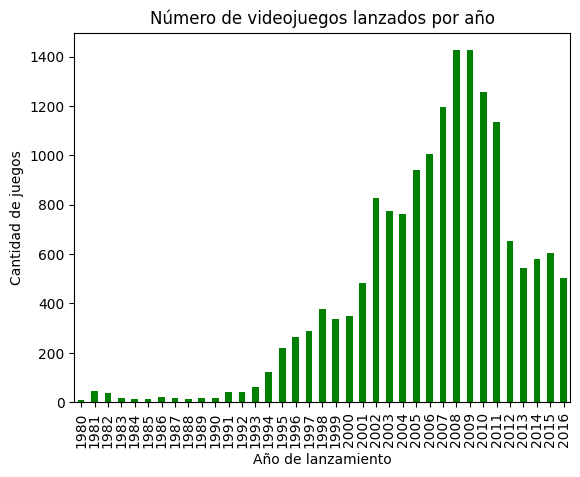

In [19]:
# Visualizar cantidad de juegos lanzados por año
games_year = df.groupby('year_of_release')['name'].count()
games_year.plot(kind='bar',color='green')

plt.title('Número de videojuegos lanzados por año')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Cantidad de juegos')
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario de Revisor     </b> <a class="tocSkip"></a>

Bien, correcto. El gráfico es claro, hubo un peak a fines de los 2000 y luego ha caido a niveles similares a los de inicios del 2000.

</div>


Se observa que el número de videojuegos lanzados por año fue significativamente bajo en las primeras décadas del período analizado. El valor mínimo se registra en 1980, con solo 9 títulos publicados.

A partir de la década de 1990 se aprecia un crecimiento progresivo en la cantidad de lanzamientos, alcanzando su punto máximo en 2008 y 2009, con 1425 y 1426 juegos respectivamente. Estos años representan el pico más alto de actividad dentro del dataset.

Posteriormente, se observa una tendencia descendente en el número de lanzamientos anuales.

### Plataformas con mayor venta historica

Text(0, 0.5, 'Ventas historicas')

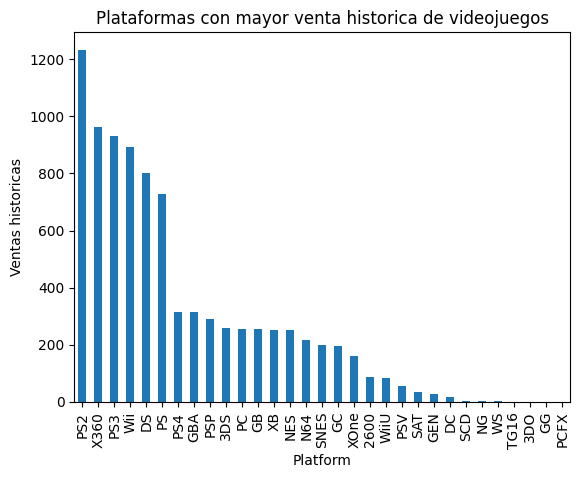

In [20]:
# Visualizar el comportamiento de ventas en las diferentes plataformas
platform_sales = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
platform_sales.plot(kind='bar')
plt.title('Plataformas con mayor venta historica de videojuegos')
plt.xlabel('Platform')
plt.ylabel('Ventas historicas')

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Muy bien con el gráfico, dado que las barras están ordenadas, se puede apreciar claramente las plataformas más exitosas

</div>

In [21]:
# Visualizar el comprtamiento de las plataformas en el tiempo
top6 = platform_sales.head(6).index
platform_life = df.pivot_table(index='year_of_release',columns='platform',values='total_sales',aggfunc='sum')
platform_life[top6]

platform,PS2,X360,PS3,Wii,DS,PS
year_of_release,,,,,,
1980,NaN,NaN,NaN,NaN,NaN,NaN
1981,NaN,NaN,NaN,NaN,NaN,NaN
1982,NaN,NaN,NaN,NaN,NaN,NaN
1983,NaN,NaN,NaN,NaN,NaN,NaN
1984,NaN,NaN,NaN,NaN,NaN,NaN
1985,NaN,NaN,NaN,NaN,0.02,NaN
1986,NaN,NaN,NaN,NaN,NaN,NaN
1987,NaN,NaN,NaN,NaN,NaN,NaN
1988,NaN,NaN,NaN,NaN,NaN,NaN


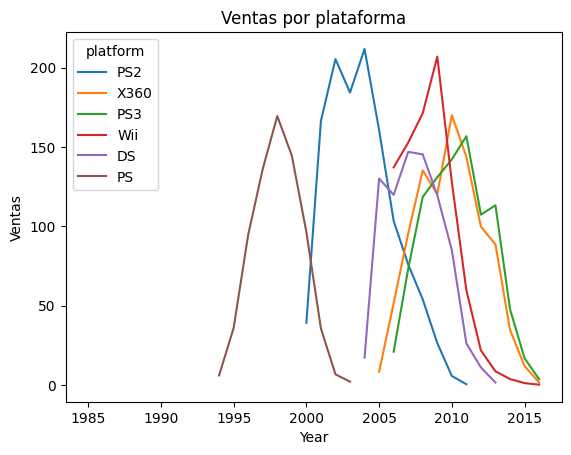

In [22]:
platform_life[top6].plot(kind='line')
plt.title('Ventas por plataforma')
plt.xlabel('Year')
plt.ylabel('Ventas')
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Excelente, muy buen gráfico, permite apreciar el periodo de vida de cada consola, incluyendo su auge y luego caída.

</div>


Se identificaron las pataformas con mayores niveles de ventas y de acuerdo a ese analisis se grafico su evolución a traves del tiempo.

- PS - vendio de 1994 a 2003 - 9 años
- PS2 - vendio de 2000 al 2011 - 11 años
- DS - vendio de 2004 al 2013 - 9 años
- Wii - vendio del 2006 al 2016 - 10 años
- X360 - vendio del 2005 al 2016 - 11 años
- PS3 - vendio del 2006 al 2016 - 10 años

Asi que podemos visualizar que el tiempo promedio de duración de las plataformas es de 9 a 11 años.
En la actualidad se observa un declive de las plataformas que estuvieron en auge en los ultimos años.
Para predecir ventas para el 2017, solo se deberian considerar las ultimas plataformas de venta que aun estan en el mercado.

### Plataformas con mayor venta en los ultimos años

In [23]:
# Creación de dataset con los datos mas recientes
df_2012 = df[df['year_of_release']>=2012]
df_2012['platform'].unique()

array(['PS3', 'X360', 'PS4', '3DS', 'DS', 'XOne', 'WiiU', 'Wii', 'PC',
       'PSV', 'PSP'], dtype=object)

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Excelente, muy bien con esta decisión. Efectivamente se requiere un periodo de tiempo reciente para incluir data representativa de lo que podría ocurrir en el futuro. Esto implica que solo se pueden tener consolas que aún tienen ventas. En general, para hacer forecast en industrias muy cambiantes se recomienda tener entre 2 y 4 años.

</div>

In [24]:
top_platforms = (df_2012.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(5).index)
df_2012_top = df_2012[df_2012['platform'].isin(top_platforms)]

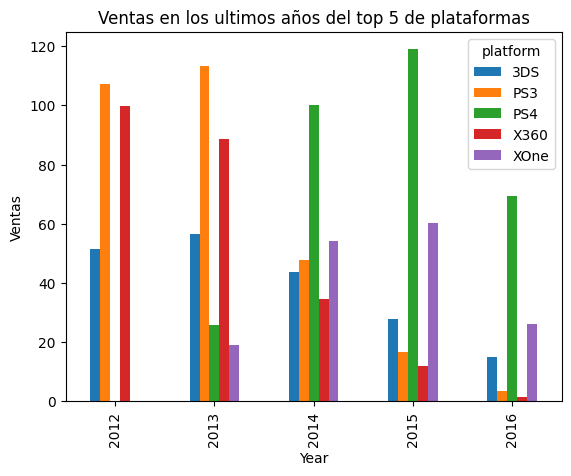

In [25]:
# Visualización de las plataformas con mas ventas en los ultimos años
platform_top = df_2012_top.pivot_table(index='year_of_release',columns='platform',values='total_sales',aggfunc='sum')

platform_top.plot(kind='bar')
plt.title('Ventas en los ultimos años del top 5 de plataformas')
plt.xlabel('Year')
plt.ylabel('Ventas')
plt.show()

Al analizar el período 2012–2016, se observa una clara transición generacional: mientras plataformas como PS3 y X360 muestran una disminución progresiva en sus ventas, nuevas plataformas como PS4 y XOne presentan un crecimiento sostenido y se consolidan como las principales en el mercado hacia 2017

### Diagramas de caja para las ventas globales

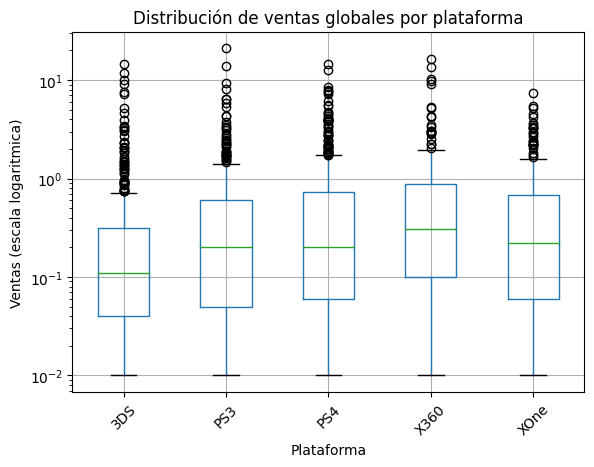

In [26]:

df_2012_top.boxplot(column='total_sales', by='platform')

plt.xticks(rotation=45)
plt.yscale('log')
plt.title('Distribución de ventas globales por plataforma')
plt.suptitle('')  
plt.xlabel('Plataforma')
plt.ylabel('Ventas (escala logaritmica)')

plt.show()

<div class="alert alert-block alert-warning">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Bien con el gráfico de boxplots, sin embargo, nota que a causa de los outliers no podemos ver la variabilidad de cada consola (las cajas son muy pequeñitas). En este caso se puede realizar el mismo gráfico pero reemplazando la escala normal por una escala logarítmica o agregando un gráfico adicional con la escala normal pero limitada a valores más pequeños (una especie de zoom al gráfico original).

</div>

El diagrama de caja revela que las plataformas tienen muchos outliers, lo cual podria interpretarse como ventas de videojuegos que se sale por completo de los estandares.
Las medianas se mantienen relativamente bajas en todas las plataformas, lo que indica que la mayoría de los juegos generan ingresos modestos.
La diferencia entre la media y la mediana confirma la existencia de un sesgo positivo provocado por unos pocos títulos de alto desempeño.

*Se utiliza escala logaritmica en el eje Y, para visualizar mejor los outliers*

### Analisis de reseñas vs ventas

In [27]:
# Mantener unicamente los datos de la plataforma elegida
ps4_scores = df_2012_top[df_2012_top['platform']=='PS4']

In [28]:
corr_user = ps4_scores['user_score'].corr(ps4_scores['total_sales'])
corr_critic = ps4_scores['critic_score'].corr(ps4_scores['total_sales'])

corr_user, corr_critic

(-0.031957110204556376, 0.40656790206178095)

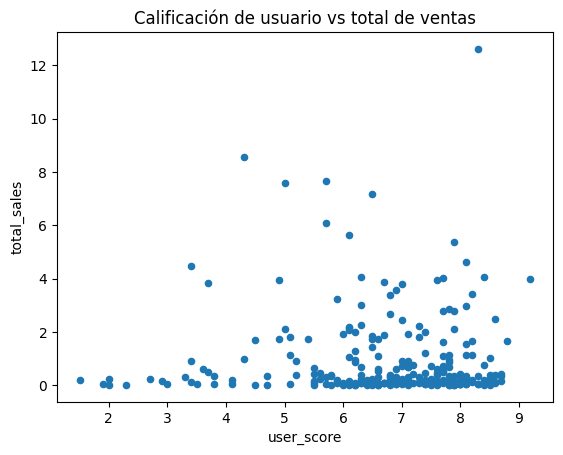

In [38]:
ps4_scores.plot(x='user_score',y='total_sales', kind='scatter')
plt.title('Calificación de usuario vs total de ventas')
plt.show()

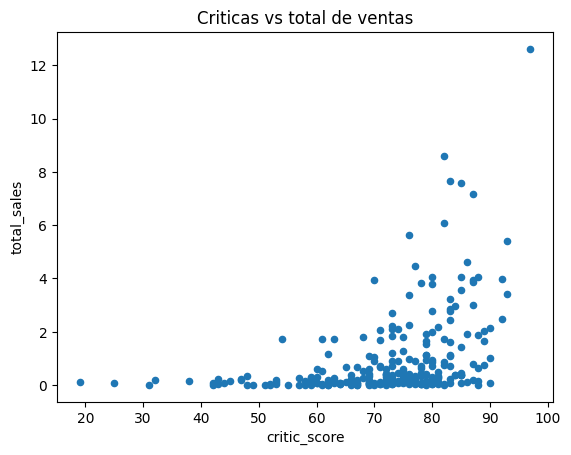

In [39]:
ps4_scores.plot(x='critic_score',y='total_sales', kind='scatter')
plt.title('Criticas vs total de ventas')
plt.show()

<div class="alert alert-block alert-warning">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

Se muestra con claridad las correlaciones, pero lo ideal sería plantear también dos gráficos de dispersión, uno para score de crítica vs ventas y otro de user score vs ventas.


</div>

El análisis de correlación muestra que las reseñas de usuarios no presentan una relación significativa con las ventas globales de PS4 (r ≈ -0.03). En contraste, las reseñas de críticos presentan una correlación positiva moderada (r ≈ 0.41), lo que sugiere que una mejor evaluación profesional tiende a asociarse con mayores ventas.
No obstante, la correlación no es suficientemente alta como para afirmar que las calificaciones son el único factor determinante del éxito comercial. Esto indica que otros elementos, como el posicionamiento de la franquicia, el marketing y la popularidad previa del título, también desempeñan un papel importante en el desempeño en ventas.

### Videojuegos con mayores ventas en distintas plataformas

In [29]:
# Escoger juegos para su analisis en multiplataformas
df_2012_top['name'].unique()
# Flitrar dataset por juego 
gta = df_2012[df_2012['name']=='Grand Theft Auto V']

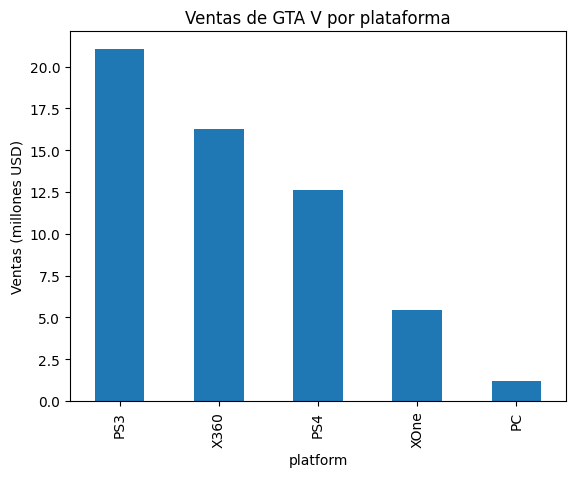

In [30]:
gta.set_index('platform')['total_sales'].plot(kind='bar')

plt.title('Ventas de GTA V por plataforma')
plt.ylabel('Ventas (millones USD)')
plt.show()

El análisis de juegos multiplataforma muestra que el desempeño en ventas varía significativamente según la plataforma. Un mismo título puede registrar ventas considerablemente mayores en consolas como PS4 o X360, en comparación con otras como PC.
Esto indica que la elección de plataforma tiene un impacto importante en el éxito comercial de un juego.

<div class="alert alert-block alert-warning">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

Bien con estas comparaciones, pero lo ideal hubiese sido comparar más juegos, no uno solo.



</div>

### Juegos por genero

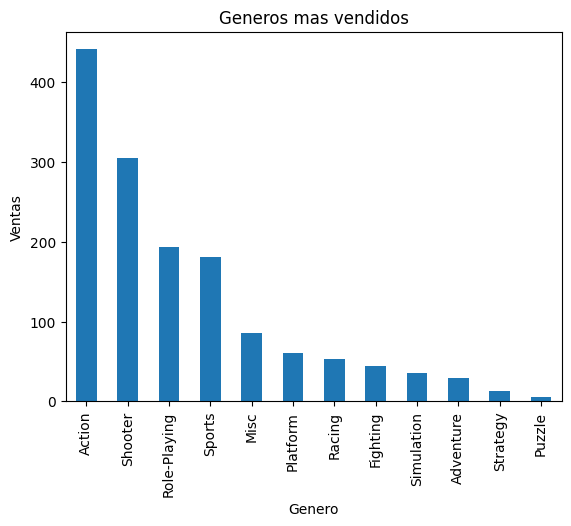

In [31]:
generos = df_2012.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
generos.plot(kind='bar')
plt.title('Generos mas vendidos')
plt.xlabel('Genero')
plt.ylabel('Ventas')
plt.show()

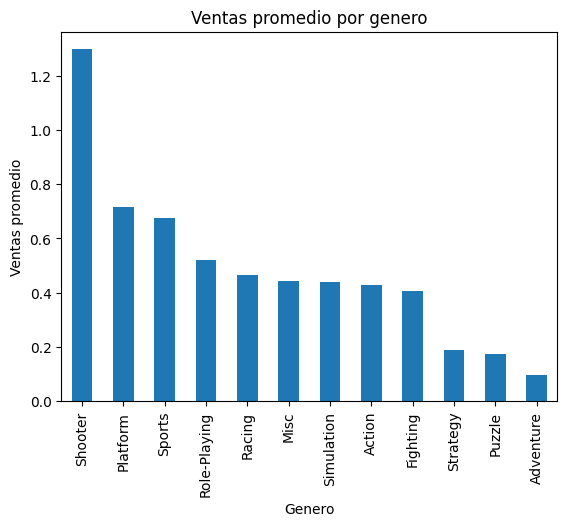

In [41]:
generos = df_2012.groupby('genre')['total_sales'].mean().sort_values(ascending=False)
generos.plot(kind='bar')
plt.title('Ventas promedio por genero')
plt.xlabel('Genero')
plt.ylabel('Ventas promedio')
plt.show()

El genero más vendido es el genero de "Action" seguido por el genero de "Plataform", sin embargo tambien visualizamos que el genero "Shooter" es el genero que genera mas ingresos en promedio.

<div class="alert alert-block alert-warning">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Ok con el gráfico, pero la rentabilidad no solo es el total de ventas, sino que también hay que ver la venta promedio por género. Te recomiendo calcular y graficar la venta promedio de cada género.

</div>

## Perfiles de usuario

In [32]:
# Obtener plataformas principales por region 
top_na = (df_2012.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5))
top_nap = (top_na / top_na.sum()) * 100

top_eu = (df_2012.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5))
top_eup = (top_eu / top_eu.sum()) * 100

top_jp = (df_2012.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5))
top_jp = (top_jp / top_jp.sum()) * 100

print(f"Plataformas por región:\n JP {top_jp}\n EU {top_eup}\n NA {top_nap}")

Plataformas por región:
 JP platform
3DS     50.719279
PS3     20.388237
PSV     12.155526
PS4      9.220637
WiiU     7.516321
Name: jp_sales, dtype: float64
 EU platform
PS4     33.858891
PS3     25.644348
X360    17.883369
XOne    12.380610
3DS     10.232781
Name: eu_sales, dtype: float64
 NA platform
X360    27.976428
PS4     21.721934
PS3     20.651219
XOne    18.601678
3DS     11.048742
Name: na_sales, dtype: float64


In [33]:
# Obtener generos principales por region
top_genre_na = (df_2012.groupby('genre')['na_sales'].sum().sort_values(ascending=False).head(5))
top_genre_eu = (df_2012.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5))
top_genre_jp = (df_2012.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5))

print(f"Generos populares por region:\n NA {top_genre_na},\n EU {top_genre_eu},\n JP {top_genre_jp}")

Generos populares por region:
 NA genre
Action          177.84
Shooter         144.77
Sports           81.53
Role-Playing     64.00
Misc             38.19
Name: na_sales, dtype: float64,
 EU genre
Action          159.34
Shooter         113.47
Sports           69.09
Role-Playing     48.53
Racing           27.29
Name: eu_sales, dtype: float64,
 JP genre
Role-Playing    65.44
Action          52.80
Misc            12.86
Simulation      10.41
Fighting         9.44
Name: jp_sales, dtype: float64


In [43]:
# Ventas por clasificación ESRB en cada región
esrb_na = df_2012.groupby('rating')['na_sales'].sum().sort_values(ascending=False)
esrb_eu = df_2012.groupby('rating')['eu_sales'].sum().sort_values(ascending=False)
esrb_jp = df_2012.groupby('rating')['jp_sales'].sum().sort_values(ascending=False)

print(f"Top 5 clasificaciones ESRB por región: \n NA: {esrb_na.head()},\n EU: {esrb_eu.head()},JP: {esrb_jp.head()}")

Top 5 clasificaciones ESRB por región: 
 NA: rating
M            231.57
E            114.37
No_rating    103.31
E10+          75.70
T             66.02
Name: na_sales, dtype: float64,
 EU: rating
M            193.96
E            113.03
No_rating     91.50
E10+          55.37
T             52.96
Name: eu_sales, dtype: float64,JP: rating
No_rating    108.84
E             28.33
T             26.02
M             21.20
E10+           8.19
Name: jp_sales, dtype: float64


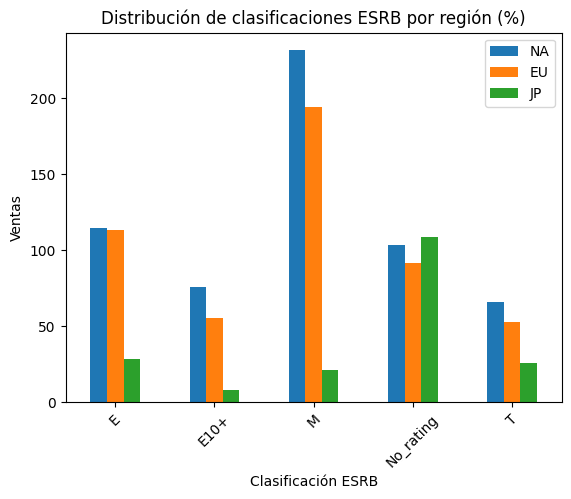

In [45]:
# Crear un DataFrame para comparar fácilmente
import pandas as pd

comparison_df = pd.DataFrame({
    'NA': esrb_na,
    'EU': esrb_eu, 
    'JP': esrb_jp
}).fillna(0)

comparison_df.plot(kind='bar')
plt.title('Distribución de clasificaciones ESRB por región (%)')
plt.xlabel('Clasificación ESRB')
plt.ylabel('Ventas')
plt.xticks(rotation=45)
plt.show()

La distribución de clasificaciones ESRB varía significativamente entre regiones. Norteamérica y Europa muestran una fuerte presencia de juegos clasificados como “M”, mientras que en Japón predominan los juegos sin clasificación ESRB. Esto probablemente se debe a que el sistema ESRB está orientado principalmente al mercado norteamericano, mientras que Japón utiliza otros sistemas de clasificación

<div class="alert alert-block alert-danger">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Para esta parte debes realizar una comparación de las tres regiones (NA, UE, JP), para ellas determina:

- Las cinco plataformas principales. Describe las variaciones en sus cuotas de mercado de una región a otra.
- Los cinco géneros principales. Explica la diferencia.
- Si las clasificaciones de ESRB afectan a las ventas en regiones individuales.


Revisa si hay diferencias en las clasificaciones ESRB
</div>

<div class="alert alert-block alert-success">
<b>Comentario de Revisor       v2     </b> <a class="tocSkip"></a>

Bien hecho, muy bien con la comparación entre las regiones. Es importante revisar diferentes dimensiones entre cada uno, esto revela puntos importantes de segmentación que podrían ser beneficiosos para un modelo de predicción. Por ejemplo, observamos que Japón es muy diferente respecto a las otras regiones en varios aspectos, tal vez esto justifique diferentes modelos o reglas para esta región.
    
</div>

## Pruebas de hipotesis


Hipotesis No1

H0 = calificaciones promedio en Xbox One y Pc son iguales

H1 = calificaciones promedio en Xbox One y Pc no son iguales


In [34]:
# Realizar prueba de hipotesis 
xone = df_2012[(df_2012['platform'] == 'XOne')]['user_score'].dropna()
pc = df_2012[(df_2012['platform'] == 'PC')]['user_score'].dropna()

alpha = 0.05

results = stats.ttest_ind(xone, pc, equal_var=False)

print(f"p-value: {results.pvalue:.5f}")

if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula: Las medias son diferentes.")
else:
    print("No rechazamos la hipótesis nula: No hay evidencia suficiente para afirmar que las medias son diferentes.")


p-value: 0.54895
No rechazamos la hipótesis nula: No hay evidencia suficiente para afirmar que las medias son diferentes.



Hipótesis No2

H0 = calificaciones promedio para Acción y Deportes son iguales

H1 = calificaciones promedio para Acción y Deportes son diferentes


In [35]:
# Datos
action = df_2012[df_2012['genre'] == 'Action']['user_score'].dropna()
sports = df_2012[df_2012['genre'] == 'Sports']['user_score'].dropna()

# Test
results1 = stats.ttest_ind(action, sports, equal_var=False)

print(f"p-value: {results1.pvalue:.5f}")

if results1.pvalue < alpha:
    print("Rechazamos la hipótesis nula: Las medias son diferentes.")
else:
    print("No rechazamos la hipótesis nula: No hay evidencia suficiente para afirmar que las medias son diferentes.")

p-value: 0.00000
Rechazamos la hipótesis nula: Las medias son diferentes.


<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Bien hecho con los tests, fueron realizados de forma correcta. 

Es importante mencionar que el t-test asume que las dos muestras tienen varianzas iguales Para verificar esa igualdad de varianzas podemos usar el **test de Levene**. Este nos dice si la variabilidad entre los grupos es *estadísticamente diferente*. En futuros notebooks podrías utilizar este test para decidir sobre la igualdad de varianzas. En corto, el flujo sería así

1. Usamos `levene()` para verificar si las varianzas son iguales.
2. Dependiendo del resultado, usamos `ttest_ind()` con el argumento `equal_var`:
   - `equal_var=True` si Levene dice que las varianzas son iguales (p > 0.05).
   - `equal_var=False` si Levene dice que las varianzas son diferentes (p < 0.05).

</div>

## Conclusion general

El análisis de los datos históricos de ventas de videojuegos permitió identificar patrones claros en el comportamiento del mercado entre 2012 y 2016, período seleccionado por representar la generación de consolas vigente previo a 2017.

Se observó que las plataformas presentan ciclos de vida definidos, con fases de crecimiento, madurez y declive. Plataformas como PS3 y X360 muestran una disminución progresiva en ventas, mientras que PS4 y XOne concentran el mayor dinamismo del mercado durante el período reciente. Esto justifica utilizar datos posteriores a 2012 para construir un modelo predictivo relevante para 2017.

El análisis de reseñas y ventas mostró que las calificaciones de críticos presentan una correlación positiva moderada con las ventas (por ejemplo, en PS4 r ≈ 0.41), mientras que las calificaciones de usuarios no muestran una relación significativa. Esto sugiere que la crítica profesional puede tener mayor impacto inicial en el desempeño comercial, aunque el éxito de un videojuego depende también de múltiples factores adicionales como franquicia, marketing y posicionamiento de marca.

El estudio regional reveló diferencias claras en las preferencias de consumo. Norteamérica y Europa presentan patrones similares, con fuerte presencia de consolas y géneros como Acción y Shooter. En contraste, Japón muestra una mayor preferencia por plataformas locales y ciertos géneros específicos, evidenciando diferencias culturales en el comportamiento del mercado.

Finalmente, las pruebas de hipótesis indicaron que las calificaciones promedio de usuarios no difieren significativamente entre Xbox One y PC, mientras que sí existen diferencias estadísticamente significativas entre los géneros Acción y Deportes. Esto sugiere que el género tiene mayor influencia en la percepción del usuario que la plataforma en sí.

En conjunto, los resultados demuestran que el mercado de videojuegos es altamente dinámico, segmentado por región y sensible al ciclo de vida de las plataformas. Para realizar predicciones confiables, es fundamental considerar factores como la generación vigente de consolas, las preferencias regionales y el género del juego, más allá de depender únicamente de las calificaciones.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Muy bien con estas conclusiones. Entre los puntos más importantes para el pronóstico de 2017 están las plataformas que serán relevantes, la segmentación de géneros por importancia de ventas y la caracterización de cada región. Para realizar una predicción del siguiente año se podría considerar cada segmento por separado para ajustar diferentes modelos.
    
Podrías mejorar tus conclusiones incluyendo algunos valores de las métricas más importantes, así las afirmaciones realizadas estarían mejor apoyadas en hechos.
    
</div>